# Runbook: CPCV backtest with PSR and the deflated Sharpe ratio (SYNTHETIC data)

> **Every committed number in this notebook comes from SYNTHETIC data.** The study runs a strategy
> family on simulated return series whose answer is known: a **no-signal control**, where no
> configuration has any edge, and a **planted weak signal**, where some do and we know how much.
> The last section runs the same pipeline on the committed SYNTHETIC sample `SYN_A`..`SYN_E`
> (random walks, so another null) read through `openquant.data.fetch`. Nothing here describes a
> real market.

AFML Chapters 11-12 and 14 make one argument from three sides: a backtest that reports the best
of many configurations reports mostly luck (§11.6, backtest overfitting); one walk-forward path
is one draw from a distribution you never see (§12.2); combinatorial purged cross-validation
(CPCV) recovers that distribution (§12.4); and the deflated Sharpe ratio (DSR, Bailey and López
de Prado 2014; §14.7.3) asks whether the best Sharpe ratio beats what the *number of trials*
alone would produce. This runbook checks that argument where the right answer is known.

**Run it on your own data.** The parameters cell reads the same environment variables as
runbook 09, so the data section runs on any OHLCV file `openquant.data` can load. Write the
executed copy and its figures outside the repository, and keep a trial registry across runs:

```bash
OPENQUANT_RUNBOOK_SOURCE=/path/to/daily_ohlcv.parquet \
OPENQUANT_RUNBOOK_SYMBOLS=ES,NQ,CL \
OPENQUANT_RUNBOOK_RANGE=2010-01-01:2024-12-31 \
OPENQUANT_RUNBOOK_REGISTRY_DIR=$HOME/.openquant/trials \
OPENQUANT_FIGURE_DIR=/tmp/cpcv-figures \
  uv run --python .venv/bin/python python notebooks/python/scripts/execute_notebook_cells.py \
    notebooks/python/12_cpcv_deflated_sharpe.ipynb --out /tmp/12_on_my_data.ipynb
```

Sections follow the research-notebook contract (#46): Setup, Hypothesis, Data, Method, Results,
Analysis, Promotion decision, Self-review, Reproducibility. This notebook also delivers the
**CPCV Sharpe-distribution** figure that the notebook runner (#45, OQ-nbr.8) left pending until
the CPCV bindings existed.

## Setup

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
from importlib.metadata import version
from pathlib import Path

import nbfigures
import numpy as np
import openquant
import polars as pl
from openquant import backtesting_engine as bte
from openquant import cross_validation as cv
from openquant import evaluation as ev

# ---- parameters (fixed before the reported run; see the trial list at the end) -----------------
SEED = 48  # the issue number; dataset (k, rep) draws from np.random.default_rng([SEED, k, rep])
ANN = 252  # bars per year, for display only: every statistic is computed per bar
T = 2520  # bars per simulated dataset that are traded (10 years of daily bars) ...
WARM = 120  # ... after a warm-up long enough for the slowest moving average

# The strategy family: moving-average crossover on log prices, long/short or long/flat.
FAST = (2, 3, 5, 8, 13, 21, 34)
SLOW = (10, 20, 40, 60, 90, 120)
MODES = ("long_short", "long_flat")
MAX_LOOKBACK = max(SLOW)  # a position depends on at most this many earlier bars (see Method)
COST_BPS = 5.0  # charged per unit of position change, so a long/short flip costs 10 bps

# Simulated returns: r_t = mu_t + SIGMA * e_t, e_t a unit-variance Student t(5) draw, and a latent
# drift mu_t = PHI * mu_{t-1} + noise whose stationary s.d. is STRENGTH * SIGMA (0 = no signal).
SIGMA = 0.01
T_DF = 5
PHI = 0.99  # the drift's half-life is about 69 bars
STRENGTHS = (0.0, 0.05, 0.1, 0.15, 0.2, 0.3)  # the power scan; 0.0 is the no-signal control
PLANTED = 0.2  # the planted-signal case of the hypothesis
N_DATASETS_CI = 200  # datasets per strength; OPENQUANT_RUNBOOK_RUNS=1000 for a tighter estimate
N_DATASETS = int(os.environ.get("OPENQUANT_RUNBOOK_RUNS", N_DATASETS_CI))
TRUTH_BARS = 250_000  # one long path per strength gives each configuration's true Sharpe ratio

# Validation.
N_GROUPS, K_TEST = 10, 3  # CPCV: C(10, 3) = 120 splits, phi[10, 3] = 36 paths
PCT_EMBARGO = 0.05  # 126 of 2520 bars, at least MAX_LOOKBACK (asserted below)
WF_TRAIN, WF_STEP = 504, 252  # walk-forward: 2 years to start, re-select every year
BENCH_SR_ANN = 0.5  # PSR is also reported against this annualised benchmark
ALPHA = 0.05  # every accept/reject rule below is at the 95% level

# ---- data source for the last section -----------------------------------------------------------
# Default: the committed SYNTHETIC sample (no network). Override with the env vars below, or set
# SOURCE to any openquant.data DataSource (e.g. a CallableSource around your vendor's API).
_src_env = os.environ.get("OPENQUANT_RUNBOOK_SOURCE", "").strip()
SOURCE = openquant.data.LocalFileSource(_src_env, name="user-file") if _src_env else None
SYMBOLS = os.environ.get("OPENQUANT_RUNBOOK_SYMBOLS", "SYN_A,SYN_B,SYN_C,SYN_D,SYN_E").split(",")
START, END = os.environ.get("OPENQUANT_RUNBOOK_RANGE", "2022-01-03:2023-12-29").split(":")
SYNTHETIC = SOURCE is None
LABEL = "SYNTHETIC" if SYNTHETIC else "user data"

# Trial registries (openquant.evaluation.TrialRegistry): one JSON file per dataset. By default
# they live in a fresh temporary directory, so a re-run starts from zero; point
# OPENQUANT_RUNBOOK_REGISTRY_DIR at a directory you keep to count trials across runs and grids.
_reg_env = os.environ.get("OPENQUANT_RUNBOOK_REGISTRY_DIR", "").strip()
REGISTRY_DIR = Path(_reg_env) if _reg_env else Path(tempfile.mkdtemp(prefix="oq-nb12-"))

CONFIGS = [
    {"family": "ma_crossover", "fast": f, "slow": s, "mode": m, "cost_bps": COST_BPS}
    for f in FAST
    for s in SLOW
    if f < s
    for m in MODES
]
N_CONFIGS = len(CONFIGS)
print(f"strategy family: {N_CONFIGS} MA-crossover configurations, costs {COST_BPS:g} bps/unit")
print(
    f"simulated datasets: {len(STRENGTHS)} signal strengths x {N_DATASETS} datasets x {T} bars"
    f" (CI default {N_DATASETS_CI})"
)
print(
    f"CPCV: N={N_GROUPS} groups, k={K_TEST} test groups, "
    f"{math.comb(N_GROUPS, K_TEST)} splits, "
    f"phi={bte.cpcv_path_count(N_GROUPS, K_TEST)} paths"
)
print(f"data section: {'committed SYNTHETIC sample' if SYNTHETIC else 'user file'}; {SYMBOLS}")

strategy family: 74 MA-crossover configurations, costs 5 bps/unit
simulated datasets: 6 signal strengths x 200 datasets x 2520 bars (CI default 200)
CPCV: N=10 groups, k=3 test groups, 120 splits, phi=36 paths
data section: committed SYNTHETIC sample; ['SYN_A', 'SYN_B', 'SYN_C', 'SYN_D', 'SYN_E']


## Hypothesis

A researcher backtests all 74 configurations of a moving-average crossover family, reports the
best one, and asks whether its Sharpe ratio is evidence of skill. Stated before the full run,
decided over the simulated datasets at the 5% level:

- **H1 (no-signal control: deflation controls false discoveries).** When no configuration has an
  edge, (a) the naive test, PSR(0) > 0.95 on the in-sample best configuration, fires in **more
  than 5%** of datasets (exact one-sided binomial test against 5%), and (b) the deflated test,
  DSR > 0.95 with N = the registry's trial count, fires in **no more than 5%** (the same binomial
  test does *not* reject 5%).
- **H2 (planted weak signal: deflation keeps real discoveries).** At the planted strength (drift
  s.d. 0.2 σ, where the best configuration's true annualised Sharpe ratio is about 1.7, see
  *Data*), DSR > 0.95 in **more than half** of datasets (exact one-sided binomial test against
  50%).

Also reported, without a pass/fail rule: the CPCV distribution of path Sharpe ratios for the
select-the-best procedure, the single walk-forward path, PSR against a benchmark of 0.5
annualised, MinTRL, and the same statistics across the whole power scan.

What theory predicts. Under the null every configuration's true Sharpe ratio is zero (slightly
negative after costs), so the best of 74 is selected on noise: its in-sample Sharpe ratio is
biased upwards and its out-of-sample paths should centre at or below zero. The 74 configurations
are strongly correlated (they are all trend rules on one series), so the effective number of
independent trials is well below 74, and DSR, which takes N at face value, should be
*conservative*: fewer false positives than 5%, and lower power under the signal.

## Data

**Simulated datasets (the study).** Each dataset is one return series of `WARM + T` = 2,640 daily
bars: $r_t = \mu_t + \sigma\,\varepsilon_t$ with $\sigma = 1\%$ and $\varepsilon_t$ a Student
$t_5$ draw scaled to unit variance (fat tails, so PSR's skewness and kurtosis terms matter). The
drift $\mu_t = 0.99\,\mu_{t-1} + \eta_t$ is a latent AR(1) whose stationary standard deviation is
`STRENGTH` $\times\,\sigma$. At strength 0 there is no drift at all: **the no-signal control**.
With a persistent drift, trend rules earn money, and how much is knowable: each configuration's
**true Sharpe ratio** is measured on one 250,000-bar path per strength.

Dataset `rep` at strength index `k` draws from `default_rng([48, k, rep])`, so dataset 0 is the
same whatever `OPENQUANT_RUNBOOK_RUNS` is. Dataset 0 at strength 0 and at strength 0.2 are the
two **headline datasets** shown in detail; they were fixed as "dataset 0" before the run.

In [2]:
def simulate(k: int, rep: int, strength: float, n_bars: int = WARM + T) -> np.ndarray:
    """One simulated return series (see Data). Rows are bars."""
    rng = np.random.default_rng([SEED, k, rep])
    eps = rng.standard_t(T_DF, size=n_bars) / math.sqrt(T_DF / (T_DF - 2))
    r = SIGMA * eps
    if strength > 0.0:
        sd = strength * SIGMA
        eta = rng.normal(0.0, sd * math.sqrt(1.0 - PHI**2), size=n_bars)
        mu = np.empty(n_bars)
        m = rng.normal(0.0, sd)  # start in the stationary distribution
        for t in range(n_bars):
            m = PHI * m + eta[t]
            mu[t] = m
        r = r + mu
    return r


WINDOWS = sorted(set(FAST) | set(SLOW))


def positions(r: np.ndarray) -> np.ndarray:
    """Position of every configuration at the closes before bars WARM-1 .. n-1: (n - WARM + 1,
    N_CONFIGS). Row j + 1 is the position held over sample j (bar WARM + j), row j the one before.

    The w-bar moving average of log closes, less the latest log close, is a linearly weighted
    sum of the last w - 1 log returns; computing it that way (a direct convolution) makes each
    position a function of those returns alone, bit for bit, which the no-lookahead test needs.
    A running cumulative sum would carry rounding from the whole history.
    """
    lr = np.log1p(r)
    c = np.arange(WARM - 1, len(r))  # the closes at which positions are set
    dev = {}  # (moving average - latest log close) at those closes
    for w in WINDOWS:
        kernel = (w - 1 - np.arange(w - 1)) / w  # weight of the log return j bars back
        dev[w] = -np.convolve(lr, kernel)[c - 1]
    pos = np.empty((len(c), N_CONFIGS))
    for j, cfg in enumerate(CONFIGS):
        up = dev[cfg["fast"]] > dev[cfg["slow"]]
        pos[:, j] = np.where(up, 1.0, -1.0 if cfg["mode"] == "long_short" else 0.0)
    return pos


def strategy_returns(r: np.ndarray) -> np.ndarray:
    """Net returns of every configuration: an (n_bars - WARM, N_CONFIGS) array.

    Sample j is bar i = WARM + j. The position held over bar i is set at the close before it,
    from moving averages of log closes up to and including that close; the cost is charged on
    bar i for the change of position at that close.
    """
    pos = positions(r)
    held, prev = pos[1:], pos[:-1]
    return held * r[WARM:, None] - COST_BPS * 1e-4 * np.abs(held - prev)


def ratio(mean: np.ndarray, sd: np.ndarray) -> np.ndarray:
    """mean / sd, and 0 where sd is 0: a configuration that never trades earns a Sharpe of 0
    (a NaN would otherwise win every argmax)."""
    return np.where(sd > 0.0, mean / np.where(sd > 0.0, sd, 1.0), 0.0)


def sharpe(x: np.ndarray) -> np.ndarray:
    """Per-bar Sharpe ratio of each column (sample s.d.), as openquant.evaluation computes it."""
    return ratio(x.mean(axis=0), x.std(axis=0, ddof=1))


# Ground truth: each configuration's Sharpe ratio on one very long path per strength.
TRUE_SR = {
    s: sharpe(strategy_returns(simulate(900 + k, 0, s, n_bars=WARM + TRUTH_BARS)))
    for k, s in enumerate(STRENGTHS)
}
truth = pl.DataFrame(
    {
        "drift s.d. / sigma": list(STRENGTHS),
        "best config true SR (ann.)": [float(TRUE_SR[s].max()) * math.sqrt(ANN) for s in STRENGTHS],
        "median config true SR (ann.)": [
            float(np.median(TRUE_SR[s])) * math.sqrt(ANN) for s in STRENGTHS
        ],
        "configs with true SR > 0": [int((TRUE_SR[s] > 0).sum()) for s in STRENGTHS],
    }
)
with pl.Config(tbl_cols=-1, float_precision=2, tbl_hide_dataframe_shape=True):
    print(f"Ground truth from one {TRUTH_BARS:,}-bar path per strength (SYNTHETIC)")
    print(truth)
best_true_planted = CONFIGS[int(np.argmax(TRUE_SR[PLANTED]))]
print("best configuration at the planted strength:", best_true_planted)

Ground truth from one 250,000-bar path per strength (SYNTHETIC)
┌────────────────────┬─────────────────────┬───────────────────────┬──────────────────────────┐
│ drift s.d. / sigma ┆ best config true SR ┆ median config true SR ┆ configs with true SR > 0 │
│ ---                ┆ (ann.)              ┆ (ann.)                ┆ ---                      │
│ f64                ┆ ---                 ┆ ---                   ┆ i64                      │
│                    ┆ f64                 ┆ f64                   ┆                          │
╞════════════════════╪═════════════════════╪═══════════════════════╪══════════════════════════╡
│ 0.00               ┆ 0.00                ┆ -0.06                 ┆ 1                        │
│ 0.05               ┆ 0.17                ┆ 0.08                  ┆ 55                       │
│ 0.10               ┆ 0.74                ┆ 0.46                  ┆ 74                       │
│ 0.15               ┆ 1.19                ┆ 0.82                  ┆ 74 

## Method

**Strategy family.** A crossover of the `fast`- and `slow`-bar moving averages of log closes,
`fast` in {2, 3, 5, 8, 13, 21, 34} and `slow` in {10, 20, 40, 60, 90, 120} with fast < slow,
either long/short or long/flat: **74 configurations**. The position held over bar $i$ is decided
at the previous close from closes up to that close. Costs: 5 bps per unit of position change.
Every configuration's net return series is recorded in an `openquant.evaluation.TrialRegistry`,
one per dataset, before any statistic is computed; DSR takes N and the Sharpe-ratio dispersion
from the registry.

**The procedure being validated** is "select the configuration with the highest Sharpe ratio on
the data you have, then trade it". Three ways to judge it:

| | What is reported | Uses |
| --- | --- | --- |
| **Naive** | the in-sample best Sharpe ratio, PSR(0) and PSR(0.5 ann.) | all 2,520 bars for selection *and* evaluation |
| **Walk-forward** | one out-of-sample path: select on bars [0, t), trade [t, t+252), t = 504, 756, ... | `WF_TRAIN`, `WF_STEP` |
| **CPCV** | $\varphi[10,3] = 36$ out-of-sample paths: in each of the 120 splits, select on the training groups, trade the 3 test groups; `backtesting_engine.assemble_cpcv_paths` gives the path-to-split map that stitches the paths | `cross_validation.cpcv_splits`, `cpcv_paths`, `backtesting_engine.run_cpcv` |
| **Deflated** | DSR = PSR against SR0, the expected best Sharpe ratio of N skill-less trials | the registry's N and σ(SR) |

**Purging and embargo.** Sample $j$'s label is the return of bar $i = 120 + j$, a span from the
close before it to its own close, given to CPCV as integer bar positions. Purging drops every
training sample whose span overlaps a test span. A position depends on at most the 120 preceding
bars (the slowest average, plus the previous position for the cost), so a training sample less
than 120 bars *after* a test block would carry test-period prices in its features: the embargo
(`pct_embargo` = 0.05, 126 bars, applied after each test block from the end of the purge, AFML
Snippet 7.3 as fixed in #170) removes those. Samples before a test block cannot see it and are
not embargoed. The tests below check all of this, including that corrupting every test-period
return leaves every training sample's net return bit-identical.

In [3]:
N_SPLITS = math.comb(N_GROUPS, K_TEST)
PATHS = cv.cpcv_paths(N_GROUPS, K_TEST)
N_PATHS = PATHS.shape[0]


def spans(n: int) -> tuple[np.ndarray, np.ndarray]:
    """Label spans of n samples, in bar positions: sample j runs from close WARM+j-1 to WARM+j."""
    t1 = np.arange(WARM, WARM + n)
    return t1 - 1, t1


def embargo_pct(n: int) -> float:
    """The configured embargo, raised if needed so it covers MAX_LOOKBACK samples."""
    return max(PCT_EMBARGO, (MAX_LOOKBACK + 0.5) / n)


T0, T1 = spans(T)
SPLITS = cv.cpcv_splits(T0, T1, N_GROUPS, K_TEST, embargo_pct(T))
assert len(SPLITS) == N_SPLITS and N_PATHS == bte.cpcv_path_count(N_GROUPS, K_TEST)


def train_masks(splits: list[dict], n: int) -> np.ndarray:
    m = np.zeros((len(splits), n))
    for s, sp in enumerate(splits):
        m[s, sp["train_indices"]] = 1.0
    return m


MASKS = train_masks(SPLITS, T)


def masked_sharpes(R: np.ndarray, masks: np.ndarray) -> np.ndarray:
    """Per-bar Sharpe ratio of every configuration on every split's training samples."""
    n = masks.sum(axis=1, keepdims=True)
    mean = (masks @ R) / n
    var = (masks @ (R * R) - n * mean**2) / (n - 1)
    return ratio(mean, np.sqrt(np.maximum(var, 0.0)))


def split_of(splits: list[dict], paths: np.ndarray) -> np.ndarray:
    """(n_paths, n): which split's out-of-sample result each path uses for each sample,
    from backtesting_engine.assemble_cpcv_paths applied to the split ids themselves."""
    ids = [np.full(len(sp["test_indices"]), float(s)) for s, sp in enumerate(splits)]
    return bte.assemble_cpcv_paths(ids, splits, paths).astype(np.intp)


SPLIT_OF = split_of(SPLITS, PATHS)


def cpcv_select(R: np.ndarray, splits: list[dict], masks: np.ndarray, which: np.ndarray):
    """CPCV of the select-the-best procedure: (chosen config per split, per-split OOS returns,
    the (n_paths, n) path returns)."""
    chosen = masked_sharpes(R, masks).argmax(axis=1)
    split_returns = [R[sp["test_indices"], c] for sp, c in zip(splits, chosen)]
    return chosen, split_returns, R[np.arange(R.shape[0]), chosen[which]]


def walk_forward(R: np.ndarray, train: int = WF_TRAIN, step: int = WF_STEP) -> np.ndarray:
    """One anchored walk-forward path: select on [0, t), trade [t, t + step)."""
    out = []
    for t in range(train, len(R), step):
        out.append(R[t : t + step, int(sharpe(R[:t]).argmax())])
    return np.concatenate(out)


def evaluate(R: np.ndarray, splits=SPLITS, masks=MASKS, which=SPLIT_OF) -> dict:
    """Naive, deflated, walk-forward and CPCV statistics of the select-the-best procedure."""
    srs = sharpe(R)
    best = int(srs.argmax())
    rb = R[:, best]
    sr_std = float(srs.std())  # population s.d., as TrialRegistry.sharpe_std
    _, _, path_ret = cpcv_select(R, splits, masks, which)
    return {
        "best": best,
        "is_sr": float(srs[best]),
        "psr0": ev.probabilistic_sharpe_ratio(rb, 0.0),
        "dsr": ev.deflated_sharpe_ratio(rb, n_trials=R.shape[1], sharpe_std=sr_std),
        "sr0": ev.expected_max_sharpe(R.shape[1], sr_std),
        "path_sr": sharpe(path_ret.T),
        "wf_sr": float(sharpe(walk_forward(R)[:, None])[0]),
    }


print(f"{N_SPLITS} splits; each group tested in {math.comb(N_GROUPS - 1, K_TEST - 1)} of them")
print("path 0 takes groups 0..9 from splits", PATHS[0].tolist())
print(
    "training samples per split: min",
    int(MASKS.sum(axis=1).min()),
    "max",
    int(MASKS.sum(axis=1).max()),
    f"of {T}; embargo {math.ceil(embargo_pct(T) * T)} samples after each test block",
)

120 splits; each group tested in 36 of them
path 0 takes groups 0..9 from splits [0, 0, 0, 1, 2, 3, 4, 5, 6, 7]
training samples per split: min 1380 max 1763 of 2520; embargo 126 samples after each test block


### No-lookahead tests

Three checks, each with a counter-check that shows it can fail:

1. **The strategy is causal.** Replacing every bar from bar $i$ on leaves every position up to and
   including the one held over bar $i$ unchanged (so returns before $i$ are unchanged).
2. **Purge and embargo.** In every split, no training span overlaps a test span, and no training
   sample has a test sample among its `MAX_LOOKBACK` preceding bars.
3. **End to end.** Replacing *every test-period return* of every split with noise and rebuilding
   all 74 strategies leaves the training-set Sharpe ratios of every split bit-identical, so the
   selection cannot see the test data. With the embargo switched off the same corruption does move
   them.

In [4]:
r0 = simulate(0, 0, 0.0)
R0 = strategy_returns(r0)
junk = np.random.default_rng([SEED, 10**6])

# 1. Causality: corrupt bars from WARM + 1000 on.
cut = 1000
tampered = r0.copy()
tampered[WARM + cut :] = junk.normal(0.0, 0.05, size=len(r0) - WARM - cut)
Rt = strategy_returns(tampered)
assert np.array_equal(Rt[:cut], R0[:cut]), "a return before the corrupted bar changed"
# ... and the position held over sample `cut` (row cut + 1) was set before the corrupted bar.
assert np.array_equal(positions(tampered)[: cut + 2], positions(r0)[: cut + 2])
tampered2 = r0.copy()
tampered2[WARM + cut - 1] += 0.2  # counter-check: an earlier bar does move some position
assert not np.array_equal(positions(tampered2)[cut + 1], positions(r0)[cut + 1])

# 2. Purge and embargo, split by split.
for sp in SPLITS:
    train, test = sp["train_indices"], sp["test_indices"]
    assert cv.count_train_test_overlaps(T0, T1, train, test) == 0
    is_test = np.zeros(T, bool)
    is_test[test] = True
    seen = np.convolve(is_test, np.ones(MAX_LOOKBACK), mode="full")[:T]  # test bars in [j-120, j]
    lagged = np.concatenate([[0.0], seen[:-1]])  # test bars in [j-120, j-1]
    assert not (lagged[train] > 0).any(), f"split {sp['split_id']}: train sees test-period bars"
purged = sum(len(sp["purged_indices"]) for sp in SPLITS)
embargoed = sum(len(sp["embargo_indices"]) for sp in SPLITS)


# 3. End to end: corrupt all test-period returns of each split, rebuild the strategies.
def training_data_after_corruption(splits: list[dict]) -> bool:
    """True if, for every split, corrupting its test-period returns and rebuilding all 74
    strategies leaves every training sample's net return bit-identical."""
    same = True
    for sp in splits:
        r = r0.copy()
        r[WARM + sp["test_indices"]] = junk.normal(0.0, 0.05, size=len(sp["test_indices"]))
        train = sp["train_indices"]
        same &= np.array_equal(strategy_returns(r)[train], R0[train])
    return same


assert training_data_after_corruption(SPLITS), "training returns saw test-period data"
no_embargo = cv.cpcv_splits(T0, T1, N_GROUPS, K_TEST, 0.0)
assert not training_data_after_corruption(no_embargo), "the end-to-end check has no teeth"
print("1. causality: positions up to bar", cut, "unchanged when later bars are replaced")
print(f"2. purge/embargo: 0 overlaps in {N_SPLITS} splits; no training sample sees a test bar")
print(f"   ({purged} purged and {embargoed} embargoed sample-splits in total)")
print("3. end to end: every training return bit-identical after corrupting every test period;")
print("   with pct_embargo=0 the same corruption changes them")

1. causality: positions up to bar 1000 unchanged when later bars are replaced
2. purge/embargo: 0 overlaps in 120 splits; no training sample sees a test bar
   (504 purged and 31752 embargoed sample-splits in total)
3. end to end: every training return bit-identical after corrupting every test period;
   with pct_embargo=0 the same corruption changes them


## Results

### The two headline datasets

Dataset 0 of the no-signal control and dataset 0 of the planted signal, in full. All 74
configurations are recorded in a trial registry per dataset first; everything below reads N and
σ(SR) from it.

In [5]:
def registry_for(name: str, R: np.ndarray, dataset: dict) -> ev.TrialRegistry:
    reg = ev.TrialRegistry(REGISTRY_DIR / f"nb12-{name}.json")
    for j, cfg in enumerate(CONFIGS):
        reg.record({**cfg, "dataset": dataset}, R[:, j])
    return reg


SAFEGUARDS = {
    "survivorship_bias_control": "simulated series; nothing is delisted",
    "look_ahead_control": "positions from closes before each bar; purge + embargo >= 120 bars, "
    "tested by corrupting every test period",
    "data_mining_control": "all 74 configurations recorded in a TrialRegistry before selection",
    "cost_assumption": f"{COST_BPS:g} bps per unit of position change",
    "multiple_testing_control": "deflated Sharpe ratio with the registry's trial count",
}

headline = {}
for name, k in (("null", STRENGTHS.index(0.0)), ("planted", STRENGTHS.index(PLANTED))):
    R = strategy_returns(simulate(k, 0, STRENGTHS[k]))
    reg = registry_for(name, R, {"simulated": name, "strength": STRENGTHS[k], "rep": 0})
    res = evaluate(R)
    chosen, split_returns, path_ret = cpcv_select(R, SPLITS, MASKS, SPLIT_OF)
    assert np.array_equal(path_ret, bte.assemble_cpcv_paths(split_returns, SPLITS, PATHS))
    run = bte.run_cpcv(
        T0,
        T1,
        split_returns,
        n_groups=N_GROUPS,
        test_groups=K_TEST,
        pct_embargo=embargo_pct(T),
        mode_provenance=f"runbook 12 ({name}): select the best of {N_CONFIGS} MA crossovers",
        trials_count=reg.n_trials,
        safeguards=SAFEGUARDS,
    )
    # The engine's own path statistics agree with the stitched paths.
    eng_mean = np.array([p["mean_return"] for p in run["path_distribution"]])
    assert np.allclose(eng_mean, path_ret.mean(axis=1), rtol=1e-9, atol=1e-15)
    assert run["path_count"] == N_PATHS
    rb = R[:, res["best"]]
    dsr_registry = reg.deflated_sharpe_ratio(rb)
    assert abs(dsr_registry - res["dsr"]) < 1e-9
    headline[name] = {
        **res,
        "R": R,
        "reg": reg,
        "run": run,
        "chosen": chosen,
        "dsr": dsr_registry,
        "true_sr": float(TRUE_SR[STRENGTHS[k]][res["best"]]),
        "psr_bench": ev.probabilistic_sharpe_ratio(rb, BENCH_SR_ANN / math.sqrt(ANN)),
        "mintrl0": ev.minimum_track_record_length(rb, 0.0, ALPHA),
        "mintrl_sr0": ev.minimum_track_record_length(rb, res["sr0"], ALPHA),
    }

a = math.sqrt(ANN)


def years(x: float) -> str:
    return "never (SR <= benchmark)" if math.isinf(x) else f"{x / ANN:.1f} years"


rows = []
for name, h in headline.items():
    cfg = CONFIGS[h["best"]]
    ps = h["path_sr"] * a
    rows.append(
        {
            "dataset 0": name,
            "trials (registry)": h["reg"].n_trials,
            "in-sample best": f"{cfg['fast']}/{cfg['slow']} {cfg['mode']}",
            "IS SR": h["is_sr"] * a,
            "true SR": h["true_sr"] * a,
            "PSR(0)": h["psr0"],
            f"PSR({BENCH_SR_ANN:g})": h["psr_bench"],
            "SR0": h["sr0"] * a,
            "DSR": h["dsr"],
            "WF SR": h["wf_sr"] * a,
            "CPCV median": float(np.median(ps)),
            "CPCV 5%": float(np.quantile(ps, 0.05)),
            "CPCV 95%": float(np.quantile(ps, 0.95)),
        }
    )
table = pl.DataFrame(rows)
with pl.Config(tbl_cols=-1, tbl_width_chars=220, float_precision=2, tbl_hide_dataframe_shape=True):
    print(
        "Headline datasets (SYNTHETIC). Sharpe ratios annualised (x sqrt 252); PSR/DSR probabilities"
    )
    print(table)
for name, h in headline.items():
    print(
        f"{name:8s} MinTRL vs SR*=0: {years(h['mintrl0'])}; vs SR0: {years(h['mintrl_sr0'])}"
        f" (sample: {T / ANN:.0f} years) | registry sigma(SR) {h['reg'].sharpe_std() * a:.2f} ann."
        f" | CPCV paths with SR > 0: {int((h['path_sr'] > 0).sum())}/{N_PATHS}"
    )

Headline datasets (SYNTHETIC). Sharpe ratios annualised (x sqrt 252); PSR/DSR probabilities
┌───────────┬───────────────────┬──────────────────┬───────┬─────────┬────────┬──────────┬──────┬──────┬───────┬─────────────┬─────────┬──────────┐
│ dataset 0 ┆ trials (registry) ┆ in-sample best   ┆ IS SR ┆ true SR ┆ PSR(0) ┆ PSR(0.5) ┆ SR0  ┆ DSR  ┆ WF SR ┆ CPCV median ┆ CPCV 5% ┆ CPCV 95% │
│ ---       ┆ ---               ┆ ---              ┆ ---   ┆ ---     ┆ ---    ┆ ---      ┆ ---  ┆ ---  ┆ ---   ┆ ---         ┆ ---     ┆ ---      │
│ str       ┆ i64               ┆ str              ┆ f64   ┆ f64     ┆ f64    ┆ f64      ┆ f64  ┆ f64  ┆ f64   ┆ f64         ┆ f64     ┆ f64      │
╞═══════════╪═══════════════════╪══════════════════╪═══════╪═════════╪════════╪══════════╪══════╪══════╪═══════╪═════════════╪═════════╪══════════╡
│ null      ┆ 74                ┆ 13/40 long_short ┆ 0.33  ┆ -0.04   ┆ 0.85   ┆ 0.30     ┆ 0.27 ┆ 0.57 ┆ -0.48 ┆ -0.33       ┆ -0.59   ┆ 0.03     │
│ planted   ┆ 74    

### Deflation against the number of trials

The same two datasets, replaying the registry in grid order: after $n$ configurations, the
best-so-far's Sharpe ratio, PSR(0) and DSR, and SR0, the best Sharpe ratio $n$ skill-less trials with
that dispersion would be expected to reach.

null     n=2: PSR 0.428 DSR 0.426 | n=74: PSR 0.852 DSR 0.571


planted  n=2: PSR 0.995 DSR 0.995 | n=74: PSR 1.000 DSR 1.000


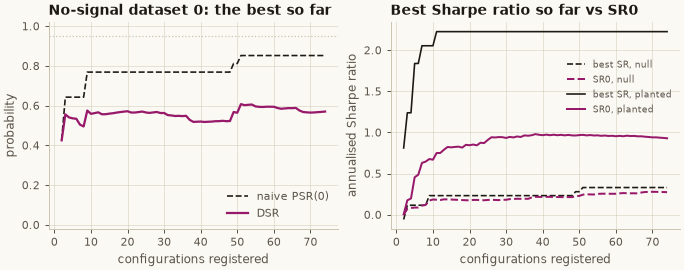

In [6]:
curves = {}
for name, h in headline.items():
    srs = sharpe(h["R"])
    psr_n, dsr_n, best_n, sr0_n = [], [], [], []
    for n in range(2, N_CONFIGS + 1):
        b = int(srs[:n].argmax())
        rb = h["R"][:, b]
        psr_n.append(ev.probabilistic_sharpe_ratio(rb, 0.0))
        dsr_n.append(ev.deflated_sharpe_ratio(rb, n_trials=n, sharpe_std=float(srs[:n].std())))
        best_n.append(float(srs[b]))
        sr0_n.append(ev.expected_max_sharpe(n, float(srs[:n].std())))
    curves[name] = {
        "n": np.arange(2, N_CONFIGS + 1),
        "psr": np.array(psr_n),
        "dsr": np.array(dsr_n),
        "best": np.array(best_n) * math.sqrt(ANN),
        "sr0": np.array(sr0_n) * math.sqrt(ANN),
    }
    print(
        f"{name:8s} n=2: PSR {psr_n[0]:.3f} DSR {dsr_n[0]:.3f} | "
        f"n={N_CONFIGS}: PSR {psr_n[-1]:.3f} DSR {dsr_n[-1]:.3f}"
    )


def draw(fig, c):
    left, right = fig.subplots(1, 2)
    null_c = curves["null"]
    left.axhline(1 - ALPHA, color=c["rule"], linewidth=1.0, linestyle=":")
    left.plot(null_c["n"], null_c["psr"], color=c["text"], linestyle="--", label="naive PSR(0)")
    left.plot(null_c["n"], null_c["dsr"], color=c["accent"], linewidth=1.8, label="DSR")
    left.set_ylim(-0.02, 1.02)
    left.set_title("No-signal dataset 0: the best so far")
    left.set_xlabel("configurations registered")
    left.set_ylabel("probability")
    left.legend(loc="lower right")
    for name, ls in (("null", "--"), ("planted", "-")):
        cc = curves[name]
        right.plot(cc["n"], cc["best"], color=c["text"], linestyle=ls, label=f"best SR, {name}")
        right.plot(
            cc["n"], cc["sr0"], color=c["accent"], linestyle=ls, linewidth=1.6, label=f"SR0, {name}"
        )
    right.set_title("Best Sharpe ratio so far vs SR0")
    right.set_xlabel("configurations registered")
    right.set_ylabel("annualised Sharpe ratio")
    right.legend(loc="upper right", bbox_to_anchor=(1.0, 0.86), fontsize=7.5)


nbfigures.figure(
    "nb12-dsr-vs-trials",
    draw,
    size=(7.6, 3.0),
    alt="Left: on the synthetic no-signal dataset, the naive PSR of the best configuration so far rises with the number of configurations registered while its deflated Sharpe ratio stays well below it. Right: the best Sharpe ratio so far and SR0, the expected best of that many skill-less trials, for the no-signal and planted-signal datasets.",
)

### Monte Carlo over datasets: false discoveries, power and the overfitting gap

Every strength in the scan, `N_DATASETS` datasets each. For each dataset: the in-sample best
configuration's naive PSR(0) and its DSR (N = 74, σ(SR) of that dataset's 74 trials, exactly what
its registry would hold), the CPCV path Sharpe ratios, the walk-forward Sharpe ratio, and the true
Sharpe ratio of the configuration the full sample selected.

In [7]:
mc_rows = []
path_pool = {}
digest = hashlib.sha256()
for k, s in enumerate(STRENGTHS):
    pool = []
    for rep in range(N_DATASETS):
        r = simulate(k, rep, s)
        digest.update(np.round(r, 12).tobytes())
        res = evaluate(strategy_returns(r))
        pool.append(res["path_sr"])
        mc_rows.append(
            {
                "strength": s,
                "rep": rep,
                "is_sr": res["is_sr"],
                "true_sr_selected": float(TRUE_SR[s][res["best"]]),
                "psr0": res["psr0"],
                "dsr": res["dsr"],
                "cpcv_mean": float(res["path_sr"].mean()),
                "cpcv_sd": float(res["path_sr"].std(ddof=1)),
                "wf_sr": res["wf_sr"],
            }
        )
    path_pool[s] = np.concatenate(pool)
mc = pl.DataFrame(mc_rows)
MC_HASH = "sha256:" + digest.hexdigest()
# The simulated bits differ in the last place between platforms (libm), so the hash goes to
# stderr, which the committed-output check ignores; every statistic is still compared.
print("Monte Carlo data hash:", MC_HASH, file=sys.stderr)

a = math.sqrt(ANN)
scan = (
    mc.group_by("strength")
    .agg(
        (pl.col("psr0") > 1 - ALPHA).mean().alias("naive PSR>0.95"),
        (pl.col("dsr") > 1 - ALPHA).mean().alias("DSR>0.95"),
        (pl.col("is_sr").mean() * a).alias("IS best SR"),
        (pl.col("cpcv_mean").mean() * a).alias("CPCV mean path SR"),
        (pl.col("wf_sr").mean() * a).alias("WF SR"),
        (pl.col("true_sr_selected").mean() * a).alias("true SR of selected"),
        (pl.col("cpcv_sd").mean() * a).alias("path s.d. within"),
        (pl.col("cpcv_mean").std() * a).alias("CPCV mean s.d. across"),
        (pl.col("wf_sr").std() * a).alias("WF s.d. across"),
    )
    .sort("strength")
    .with_columns(pl.Series("best true SR", [float(TRUE_SR[s].max()) * a for s in STRENGTHS]))
)
with pl.Config(tbl_cols=-1, tbl_width_chars=220, float_precision=3, tbl_hide_dataframe_shape=True):
    print(f"Power scan, {N_DATASETS} SYNTHETIC datasets per strength; SRs annualised, means")
    print(scan.select(scan.columns[:7]).with_columns(scan["best true SR"]))
    print("Dispersion: s.d. of CPCV path SRs within one dataset (mean over datasets), and s.d.")
    print("across datasets of the CPCV mean path SR and of the walk-forward SR")
    print(scan.select(["strength", *scan.columns[7:10]]))

Power scan, 200 SYNTHETIC datasets per strength; SRs annualised, means
┌──────────┬────────────────┬──────────┬────────────┬───────────────────┬────────┬─────────────────────┬──────────────┐
│ strength ┆ naive PSR>0.95 ┆ DSR>0.95 ┆ IS best SR ┆ CPCV mean path SR ┆ WF SR  ┆ true SR of selected ┆ best true SR │
│ ---      ┆ ---            ┆ ---      ┆ ---        ┆ ---               ┆ ---    ┆ ---                 ┆ ---          │
│ f64      ┆ f64            ┆ f64      ┆ f64        ┆ f64               ┆ f64    ┆ f64                 ┆ f64          │
╞══════════╪════════════════╪══════════╪════════════╪═══════════════════╪════════╪═════════════════════╪══════════════╡
│ 0.000    ┆ 0.300          ┆ 0.000    ┆ 0.390      ┆ -0.088            ┆ -0.077 ┆ -0.091              ┆ 0.003        │
│ 0.050    ┆ 0.510          ┆ 0.000    ┆ 0.516      ┆ 0.042             ┆ 0.025  ┆ 0.057               ┆ 0.166        │
│ 0.100    ┆ 0.905          ┆ 0.195    ┆ 0.953      ┆ 0.501             ┆ 0.493  ┆ 0.555 

Monte Carlo data hash: sha256:9b980640731cc39f0bbbfbf5acac158c2ff64683c5e4957e7c952375ce769827


In [8]:
def binom_tail(x: int, n: int, p: float) -> float:
    """P(X >= x) for X ~ Binomial(n, p)."""
    return sum(math.comb(n, i) * p**i * (1 - p) ** (n - i) for i in range(x, n + 1))


null = mc.filter(pl.col("strength") == 0.0)
planted = mc.filter(pl.col("strength") == PLANTED)
n0, n1 = null.height, planted.height
x_naive = int((null["psr0"] > 1 - ALPHA).sum())
x_dsr = int((null["dsr"] > 1 - ALPHA).sum())
x_pow = int((planted["dsr"] > 1 - ALPHA).sum())
p_naive = binom_tail(x_naive, n0, ALPHA)
p_dsr = binom_tail(x_dsr, n0, ALPHA)
p_pow = binom_tail(x_pow, n1, 0.5)
H1a, H1b, H2 = p_naive < ALPHA, p_dsr >= ALPHA, p_pow < ALPHA


def verdict(ok: bool) -> str:
    return "SUPPORTED" if ok else "REJECTED"


print(
    f"H1a naive PSR(0)>0.95 under the null: {x_naive}/{n0} = {x_naive / n0:.1%},"
    f" P(>= | 5%) = {p_naive:.2g} -> {verdict(H1a)}"
)
print(
    f"H1b DSR>0.95 under the null:          {x_dsr}/{n0} = {x_dsr / n0:.1%},"
    f" P(>= | 5%) = {p_dsr:.2g} -> {verdict(H1b)}"
)
print(
    f"H2  DSR>0.95 at strength {PLANTED}:        {x_pow}/{n1} = {x_pow / n1:.1%},"
    f" P(>= | 50%) = {p_pow:.2g} -> {verdict(H2)}"
)

H1a naive PSR(0)>0.95 under the null: 60/200 = 30.0%, P(>= | 5%) = 5.3e-30 -> SUPPORTED
H1b DSR>0.95 under the null:          0/200 = 0.0%, P(>= | 5%) = 1 -> SUPPORTED
H2  DSR>0.95 at strength 0.2:        161/200 = 80.5%, P(>= | 50%) = 4.2e-19 -> SUPPORTED


### CPCV path Sharpe ratios

The distribution CPCV exists to produce, for the no-signal control and the planted signal: every
path of every dataset, against the in-sample best Sharpe ratio a naive backtest would report.
This is the **CPCV Sharpe-distribution payload** (OQ-nbr.8) that the notebook runner (#45) left
open.

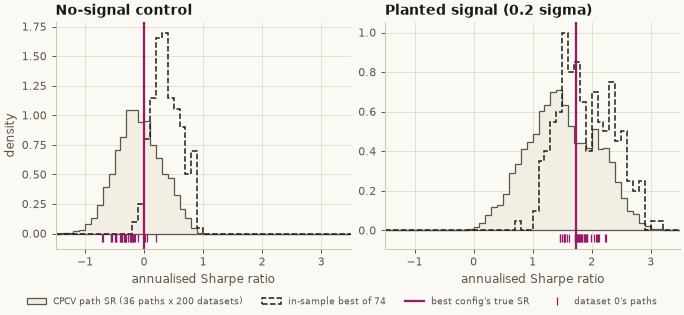

In [9]:
def draw(fig, c):
    axes = fig.subplots(1, 2, sharey=False)
    bins = np.arange(-1.5, 3.5 + 1e-9, 0.1)  # fixed edges, not derived from the data
    for ax, s, title in (
        (axes[0], 0.0, "No-signal control"),
        (axes[1], PLANTED, f"Planted signal ({PLANTED:g} sigma)"),
    ):
        sub = mc.filter(pl.col("strength") == s)
        name = "null" if s == 0.0 else "planted"
        ax.hist(
            np.clip(path_pool[s] * a, bins[0], bins[-1]),
            bins=bins,
            density=True,
            histtype="stepfilled",
            color=c["surface"],
            edgecolor=c["muted"],
            linewidth=1.0,
            label=f"CPCV path SR ({N_PATHS} paths x {N_DATASETS} datasets)",
        )
        ax.hist(
            np.clip(sub["is_sr"].to_numpy() * a, bins[0], bins[-1]),
            bins=bins,
            density=True,
            histtype="step",
            color=c["text"],
            linestyle="--",
            linewidth=1.2,
            label="in-sample best of 74",
        )
        ax.axvline(
            float(TRUE_SR[s].max()) * a,
            color=c["accent"],
            linewidth=1.8,
            label="best config's true SR",
        )
        ax.plot(
            headline[name]["path_sr"] * a,
            np.full(N_PATHS, -0.04),
            "|",
            color=c["accent"],
            markersize=7,
            label="dataset 0's paths",
        )
        ax.set_title(title)
        ax.set_xlabel("annualised Sharpe ratio")
        ax.set_xlim(bins[0], bins[-1])
    axes[0].set_ylabel("density")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncols=4, fontsize=7.5)


nbfigures.figure(
    "nb12-path-sharpe",
    draw,
    size=(7.6, 3.5),
    alt="Distributions of CPCV path Sharpe ratios and of the in-sample best-of-74 Sharpe ratio across synthetic datasets, for the no-signal control and the planted signal, with the best configuration's true Sharpe ratio marked.",
)

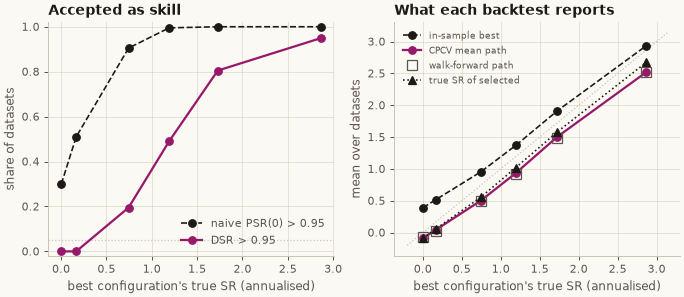

In [10]:
def draw(fig, c):
    left, right = fig.subplots(1, 2)
    x = scan["best true SR"].to_numpy()
    left.axhline(ALPHA, color=c["rule"], linestyle=":", linewidth=1.0)
    left.plot(x, scan["naive PSR>0.95"], "o--", color=c["text"], label="naive PSR(0) > 0.95")
    left.plot(x, scan["DSR>0.95"], "o-", color=c["accent"], linewidth=1.8, label="DSR > 0.95")
    left.set_ylim(-0.02, 1.02)
    left.set_xlabel("best configuration's true SR (annualised)")
    left.set_ylabel("share of datasets")
    left.set_title("Accepted as skill")
    left.legend(loc="lower right")

    lim = (min(x.min(), -0.2), max(scan["IS best SR"].max(), x.max()) + 0.2)
    right.plot(lim, lim, color=c["rule"], linewidth=1.0, linestyle=":")
    right.plot(x, scan["IS best SR"], "o--", color=c["text"], label="in-sample best")
    right.plot(
        x, scan["CPCV mean path SR"], "o-", color=c["accent"], linewidth=1.8, label="CPCV mean path"
    )
    right.plot(
        x,
        scan["WF SR"],
        "s",
        color=c["muted"],
        markerfacecolor="none",
        markersize=8,
        label="walk-forward path",
    )
    right.plot(x, scan["true SR of selected"], "^:", color=c["text"], label="true SR of selected")
    right.set_xlabel("best configuration's true SR (annualised)")
    right.set_ylabel("mean over datasets")
    right.set_title("What each backtest reports")
    right.legend(loc="upper left", fontsize=7.5)


nbfigures.figure(
    "nb12-power-bias",
    draw,
    size=(7.6, 3.3),
    alt="Left: share of synthetic datasets in which the naive PSR and the deflated Sharpe ratio accept the best configuration, against the true Sharpe ratio of the best configuration. Right: mean in-sample best, walk-forward, CPCV mean path and true Sharpe ratios against the same axis.",
)

### The data layer: the same pipeline on `fetch()` data

The committed sample is five symbols over two years, and each is a random walk, so this is one
more no-signal case, on the data layer. Each configuration trades every symbol and the returns are
averaged across symbols. Two years cannot hold 10 CPCV groups with a 120-bar embargo, so this
section uses N = 6, k = 2 (5 paths), the embargo raised to cover `MAX_LOOKBACK`, and a
walk-forward over halves and quarters of the sample. On your own data (see the top of the
notebook) this is the section that answers the question for real.

In [11]:
bars, meta = openquant.data.fetch(SYMBOLS, START, END, source=SOURCE, return_meta=True)
print("source:", meta["source"], f"| {LABEL}" + (", not market data" if SYNTHETIC else ""))
print("rows:", meta["rows"], "| dataset_hash:", meta["dataset_hash"])
closes = (
    bars.pivot(on="symbol", index="ts", values="close")
    .select(["ts", *SYMBOLS])
    .drop_nulls()
    .sort("ts")
)
px = closes.select(SYMBOLS).to_numpy()
rets = px[1:] / px[:-1] - 1.0
R_data = np.mean([strategy_returns(rets[:, i]) for i in range(len(SYMBOLS))], axis=0)
T_DATA = len(R_data)
DATA_GROUPS, DATA_K = 6, 2
t0d, t1d = spans(T_DATA)
splits_d = cv.cpcv_splits(t0d, t1d, DATA_GROUPS, DATA_K, embargo_pct(T_DATA))
paths_d = cv.cpcv_paths(DATA_GROUPS, DATA_K)
masks_d = train_masks(splits_d, T_DATA)
assert all(
    cv.count_train_test_overlaps(t0d, t1d, sp["train_indices"], sp["test_indices"]) == 0
    for sp in splits_d
)
reg_d = registry_for("data", R_data, {"source": meta["source"], "hash": meta["dataset_hash"]})
srs_d = sharpe(R_data)
best_d = int(srs_d.argmax())
rb_d = R_data[:, best_d]
_, split_ret_d, path_ret_d = cpcv_select(R_data, splits_d, masks_d, split_of(splits_d, paths_d))
wf_d = walk_forward(R_data, T_DATA // 2, T_DATA // 4)
cfg = CONFIGS[best_d]
print(
    f"traded bars: {T_DATA} ({closes['ts'][WARM + 1].date()} -> {closes['ts'][-1].date()}),"
    f" {len(SYMBOLS)} symbols averaged; trials in the registry: {reg_d.n_trials}"
)
print(
    f"in-sample best: {cfg['fast']}/{cfg['slow']} {cfg['mode']}, SR {srs_d[best_d] * a:.2f} ann.,"
    f" PSR(0) {ev.probabilistic_sharpe_ratio(rb_d, 0.0):.3f},"
    f" DSR {reg_d.deflated_sharpe_ratio(rb_d):.3f}"
    f" (SR0 {reg_d.expected_max_sharpe() * a:.2f} ann.)"
)
print(
    f"MinTRL vs 0: {years(ev.minimum_track_record_length(rb_d, 0.0, ALPHA))};"
    f" CPCV path SRs (ann.): {np.round(sharpe(path_ret_d.T) * a, 2).tolist()};"
    f" walk-forward SR {sharpe(wf_d[:, None])[0] * a:.2f}"
)

source: openquant-synthetic-sample | SYNTHETIC, not market data
rows: 2600 | dataset_hash: sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea


traded bars: 399 (2022-06-21 -> 2023-12-29), 5 symbols averaged; trials in the registry: 74
in-sample best: 13/120 long_short, SR 0.62 ann., PSR(0) 0.783, DSR 0.370 (SR0 0.89 ann.)
MinTRL vs 0: 7.0 years; CPCV path SRs (ann.): [-1.3, -1.58, -0.89, -1.14, -0.95]; walk-forward SR -2.07


## Analysis

Every number below is from the committed run on SYNTHETIC data: 200 datasets per strength, 10
years of daily bars each, 74 configurations, costs included. Sharpe ratios are annualised.

**H1 is supported: the naive test finds skill where there is none, and DSR does not.** On the
no-signal control the in-sample best of 74 has a mean Sharpe ratio of 0.39, while the
configuration it picks has a true Sharpe ratio of −0.09. Its PSR(0) clears 0.95 in 30% of datasets
(60 of 200) against a nominal 5%. DSR, deflated by the registry's 74 trials, clears 0.95 in none
of them. The deflation figure shows the mechanism on dataset 0: as configurations are added, the
best-so-far's PSR(0) climbs from 0.43 to 0.85 while its DSR stays between 0.5 and 0.6, because
SR0, the best that luck alone would reach, rises with the maximum. Dataset 0 happens not to cross
0.95 naively (PSR 0.85); its MinTRL at SR* = 0 is 24.7 years, against the 10 in the sample. The
Monte Carlo, not dataset 0, is the evidence.

**H2 is supported: DSR keeps a real edge of this size.** At the planted strength, where the best
configuration's true Sharpe ratio is 1.73, DSR accepts the in-sample best in 80.5% of datasets
(161 of 200). On dataset 0 it accepts outright (DSR 1.00; MinTRL 0.6 years against SR* = 0 and
1.6 years against SR0 = 0.93).

**DSR is conservative here, as predicted, and that has a price.** No false positives in 200, where
5% is allowed, means the deflation is stronger than this family needs. The 74 configurations are
all trend rules on one series, so they are highly correlated and the effective number of
independent trials is far below 74; DSR takes N at face value. The price is power: DSR accepts a
best configuration with a true Sharpe ratio of 0.74 in 20% of datasets, and one of 1.19 in 49%.
The naive test accepts them in 91% and 99.5%, but it also accepts nothing at all 30% of the time.
A second effect: with a real signal the trials' Sharpe ratios differ for real reasons, so σ(SR)
is larger (0.38 against 0.11 on the controls' dataset 0) and so is SR0 (0.93 against 0.27). The
formula cannot tell that dispersion from luck. Estimating the effective number of trials, for
example by clustering the trials' returns (ONC; López de Prado and Lewis 2019), would recover some
of this power; `openquant.evaluation` does not do that yet.

**CPCV and walk-forward both remove the selection bias; CPCV's path spread is not a confidence
interval.** Averaged over datasets, the in-sample best overstates the true Sharpe ratio of what it
selected by 0.3 to 0.5 at every strength (the power figure, right panel). The CPCV mean path Sharpe
ratio and the walk-forward Sharpe ratio both land within about 0.1 of the truth, slightly below it,
because they select on less data (70% of the sample for CPCV, a growing window for walk-forward).
CPCV's mean is a little less variable across datasets than the single walk-forward path (s.d. 0.31
against 0.38 on the controls, 0.55 against 0.60 at the planted strength). But the spread of the 36
paths *within* one dataset (s.d. about 0.21 at every strength) is smaller than the spread of the
CPCV mean *across* datasets (0.30 to 0.77). The paths reuse the same returns and differ only in
which training set chose the configuration for each group, so their spread measures how unstable
the selection is, not the sampling error of the Sharpe ratio. On the controls' dataset 0, 3 of 36
paths are positive (median −0.33, 5–95% range −0.59 to 0.03), for a selected configuration whose
true Sharpe ratio is −0.04. At the planted strength all 36 paths are positive (median 1.80, true
1.69).

**The data layer.** On the SYNTHETIC `SYN_A`..`SYN_E` sample, random walks traded as an equal-weight
basket, the in-sample best has a Sharpe ratio of 0.62 and a PSR(0) of 0.78. DSR is 0.37 (SR0 0.89
over 1.6 years), all five CPCV paths are negative, and the walk-forward Sharpe ratio is −2.07. It
is one more null case, and every test treats it as one. The sample is too short for this grid:
the 120-bar embargo takes most of each training set.

**Limits.** The data come from one kind of process (a persistent latent drift under fat-tailed
noise), the strategies are one kind of rule, and every dataset has 10 years of daily bars.
Correlation among trials, the shape of the signal and the sample length all move DSR's power. The
planted strength was placed after a prototype scan (see the trial list below) to show a case where
DSR should accept; the power scan is there so that no single strength carries the conclusion.

## Promotion decision

**Promote the evaluation protocol, not a strategy.**

- **Promoted as the default for every strategy-selection runbook:** record every configuration in
  an `openquant.evaluation.TrialRegistry` before selecting; report the DSR with the registry's N
  next to any PSR; report the CPCV mean path Sharpe ratio (or a walk-forward one) rather than the
  in-sample best; and state MinTRL. On data with a known answer this protocol made no false
  discovery in 200 no-signal datasets and kept 80% of a true Sharpe ratio of 1.7.
- **With two caveats written down:** DSR with the raw trial count is conservative when the trials
  are correlated, so a DSR below 0.95 on a correlated grid is weak evidence of *no* skill; and the
  spread of CPCV paths within one dataset is not a confidence interval for the Sharpe ratio.
- **Not promoted:** the MA-crossover family, which has no edge on the data-layer sample (random
  walks, as expected). Whether it has one on real data is open. Run this notebook with
  `OPENQUANT_RUNBOOK_SOURCE` and a persistent `OPENQUANT_RUNBOOK_REGISTRY_DIR` to find out.
- **Follow-ups worth filing:** an effective-number-of-trials estimate (e.g. ONC clusters of trial
  returns) for `TrialRegistry`; and a sentence on the `backtesting_engine` page that path dispersion
  reflects selection instability, not sampling error.

## Self-review checklist

- [x] **No lookahead, tested.** Positions use closes before each bar (test 1, with a counter-check).
  Purge: no training span overlaps a test span in any of the 120 splits. Embargo: 126 samples
  after each test block (≥ the 120-bar lookback), and no training sample has a test bar among its
  120 predecessors (test 2). End to end, corrupting every test-period return leaves every training
  sample's net return bit-identical in every split, and the same check fails with the embargo off (test 3). The
  embargo follows each test block only, as AFML Snippet 7.3 and #170 have it.
- [x] **Every configuration is registered** in an `openquant.evaluation.TrialRegistry` before any
  selection: 74 per dataset (printed from `n_trials` for each headline dataset and the data
  section), and DSR reads N and σ(SR) from it (asserted equal to the functional form). The
  Monte Carlo datasets use the same N and σ(SR) without writing 1,200 files.
- [x] **Costs included:** 5 bps per unit of position change in every return series, in-sample and
  out; `run_cpcv` records the cost assumption and the other four §11.4 safeguards.
- [x] **Seeds fixed**, per dataset (`default_rng([48, k, rep])`), so dataset 0 does not depend on
  the run count. The truth paths use strength indices 900+.
- [x] **The engine agrees:** `backtesting_engine.run_cpcv` on the per-split returns reproduces the
  stitched paths' means, and its path count is φ[10, 3] = 36.
- [x] **Everything is labelled SYNTHETIC**; the data section says so when `SOURCE` is the sample.
- [x] **Research trials disclosed** (next cell): the study's own design choices made before the
  reported run.

In [12]:
# Every configuration of the *study* evaluated while writing this runbook, including prototypes.
STUDY_TRIALS = [
    "prototype: 74-config grid, t(5) noise, AR(1) drift; true SR per config on a 200k-bar path "
    "for strengths 0, 0.1, 0.2, 0.3, 0.5 (to place a 'weak' signal)",
    "prototype: naive PSR vs DSR acceptance over 100 datasets at strengths 0, 0.12, 0.15, 0.18, "
    "0.2, 0.25, CPCV not yet included; the planted strength 0.2 was chosen from this scan",
    "this notebook, first executions: two stopped at the end-to-end no-lookahead test (moving"
    " averages from running cumulative sums carried rounding from the whole history; a BLAS"
    " product was compared bit for bit); a third completed while a never-trading configuration's"
    " NaN Sharpe ratio could win the walk-forward selection. Code fixes only; no parameter changed",
    f"this notebook: {len(STRENGTHS)} strengths x {N_DATASETS_CI} datasets, CPCV N=10 k=3, "
    "embargo 0.05, costs 5 bps  <- reported",
]
print(f"study configurations evaluated: {len(STUDY_TRIALS)}")
for i, t in enumerate(STUDY_TRIALS, 1):
    print(f"  {i}. {t}")
print(
    "strategy trials per dataset:",
    {name: h["reg"].n_trials for name, h in headline.items()} | {"data": reg_d.n_trials},
)

study configurations evaluated: 4
  1. prototype: 74-config grid, t(5) noise, AR(1) drift; true SR per config on a 200k-bar path for strengths 0, 0.1, 0.2, 0.3, 0.5 (to place a 'weak' signal)
  2. prototype: naive PSR vs DSR acceptance over 100 datasets at strengths 0, 0.12, 0.15, 0.18, 0.2, 0.25, CPCV not yet included; the planted strength 0.2 was chosen from this scan
  3. this notebook, first executions: two stopped at the end-to-end no-lookahead test (moving averages from running cumulative sums carried rounding from the whole history; a BLAS product was compared bit for bit); a third completed while a never-trading configuration's NaN Sharpe ratio could win the walk-forward selection. Code fixes only; no parameter changed
  4. this notebook: 6 strengths x 200 datasets, CPCV N=10 k=3, embargo 0.05, costs 5 bps  <- reported
strategy trials per dataset: {'null': 74, 'planted': 74, 'data': 74}


## Reproducibility

In [13]:
config = {
    "seed": SEED,
    "T": T,
    "warm": WARM,
    "fast": FAST,
    "slow": SLOW,
    "modes": MODES,
    "cost_bps": COST_BPS,
    "sigma": SIGMA,
    "t_df": T_DF,
    "phi": PHI,
    "strengths": STRENGTHS,
    "planted": PLANTED,
    "n_datasets": N_DATASETS,
    "cpcv": [N_GROUPS, K_TEST, PCT_EMBARGO],
    "walk_forward": [WF_TRAIN, WF_STEP],
}
print("package:      pyopenquant", version("pyopenquant"))
print("numpy:       ", np.__version__, "| polars:", pl.__version__)
print("data hash:   ", meta["dataset_hash"], f"({LABEL})")
print("seed:        ", SEED, "| datasets per strength:", N_DATASETS)
print("config:      ", hashlib.sha256(json.dumps(config).encode()).hexdigest()[:12])
print("registries:  ", "temporary directory" if not _reg_env else REGISTRY_DIR, file=sys.stderr)
print("MC data:     ", MC_HASH, file=sys.stderr)  # platform-dependent, see the Monte Carlo cell
try:
    sha = subprocess.run(
        ["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True
    ).stdout.strip()
    print("git sha:     ", sha, file=sys.stderr)
except (OSError, subprocess.CalledProcessError):
    print("git sha:      unavailable", file=sys.stderr)

package:      pyopenquant 0.1.0
numpy:        2.4.6 | polars: 1.38.1
data hash:    sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea (SYNTHETIC)
seed:         48 | datasets per strength: 200
config:       f35ee9a6f6a7


registries:   temporary directory
MC data:      sha256:9b980640731cc39f0bbbfbf5acac158c2ff64683c5e4957e7c952375ce769827
git sha:      59b868e72b9d9c08feacc09e767ad9013b1e5fdc
